In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
import math

## 设置随机种子确保复现能力


In [ ]:
## 配置模型的相关信息

@dataclass
class GPTConfig:
    block_size: int = 512  ## 文本的最大长度
    batch_size: int = 12
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768  ## 这里也可以写成hidden_size 或者是hidden_dim这里携程embd
    hidden_dim = n_embd
    dropout: float = 0.1
    head_size: int = n_embd // n_head ## 每个头的维度大小
    ## vocab_size
    ## 用gpt2的官方的tokensize
    vocab_size: int = 50257
    ## 专家数量
    shared_expert_number: int = 4
    router_expert_number: int = 10
    ## 专家隐藏层维度
    d_ff: int = hidden_dim * 2
    top_k: int = 3





In [ ]:
## 定义网络的结构
# 1. single head attention
class SingleHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        ### KVQ层
        self.key_layer = nn.Linear(config.hidden_dim, config.head_size)
        self.value_layer = nn.Linear(config.hidden_dim, config.head_size)
        self.query_layer = nn.Linear(config.hidden_dim, config.head_size)
        self.head_size = config.head_size
        self.dropout = nn.Dropout(config.dropout)

        ### 尝试学习attention的新的写法，attention_mask通过register_buffer注册
        ### 因为可以不用计算梯度，计算更快


        ### block_size就是文本的最大长度
        self.register_buffer(
            "attention_mask",
            torch.tril(
                torch.ones(config.block_size, config.block_size)
            )
        )

    def forward(self, x):
        batch_size, seq_len, hidden_dim = x.size()
        k = self.key_layer(x)
        v = self.value_layer(x)
        q = self.query_layer(x)
        weight = q @ k.transpose(-2, -1)  ## Q乘以K的转置
        weight = weight.masked_fill(
            self.attention_mask[:seq_len, : seq_len] == 0,
            float("-inf")
        )
        ## 要注意计算Wight的时候，需要除以根号下dk
        weight = F.softmax(weight, dim=-1) / math.sqrt(self.head_size)

        ## dropout需要放到weight后面
        weight = self.dropout(weight)
        output = weight @ v
        return output


In [ ]:
# 2. multi head attention
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.heads = nn.ModuleList(
            [
                SingleHeadAttention(config)
                for _ in range(config.n_head)
            ]
        )
        self.proj = nn.Linear(config.hidden_dim, config.hidden_dim)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        output = torch.cat(
            [h(x) for h in self.heads],
            dim = -1
        )
        output = self.proj(output)
        output = self.dropout(output)
        return output
    

In [ ]:
# 3. feed forward（MLP层）
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.hidden_dim, 4 * config.hidden_dim),
            nn.GELU(),
            nn.Linear(4 * config.hidden_dim, config.hidden_dim),
            nn.Dropout(config.dropout)
        )
    def forward(self, x):
        return self.net(x)


In [ ]:
# 4. block层，整体包括
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.att = MultiHeadAttention(config)  ## mha
        self.ffn = FeedForward(config)
        self.ln1 = nn.LayerNorm(config.hidden_dim)
        self.ln2 = nn.LayerNorm(config.hidden_dim)

    def forward(self, x):
        x = x + self.att(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

In [ ]:
# 5. GPT 这里需要把前面的都加进来
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        ## (embedding, position, norm, mlp, block)
        ## position embadding从 0，1，xxx的Embedding升级到rope
        ### norm layer norm  ->  rms norm
        ### mlp  ->  swiglu
        ### mha  -> gqa
        ## 学会了gpt，后面的大模型基本上就是对上面模块进行替换
        ## 基本上是这样的，最重要的是数据，如何通过数据进行预训练得到更好的模型
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.block_size = config.block_size
        self.block = nn.Sequential(
            *[Block(config) for _ in range(config.n_layer)]
        )
        self.ln_final = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        ## 非常重要，使用tie weight减少参数
        ## linear层：4 -> 8
        self.tok_emb.weight = self.lm_head.weight
        ## 初始化权重
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            ## 初始化为高斯分布
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    

    def forward(self, idx, targets=None):
        ## idx 输入是 token id
        ## targets 是目标 token ids
        ## 两个的 shape 要一样的
        batch, seq_len = idx.size() # (batch, seq_len)
        token_emb = self.tok_emb(idx)
        position_emb = self.pos_emb(
            ## 需要确保位置编码和输入的idx在同一个设备上
            torch.arange(seq_len, device=idx.device)
        )

        ## token embedding 和 position embedding为什么是可以相加的？
        x = token_emb + position_emb  ## shape : (batch, seq_size, n_embd)
        x = self.block(x)
        x = self.ln_final(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            batch, seq_len, vocab_size = logits.size()
            logits = logits.view(batch * seq_len, vocab_size)
            targets = targets.view(batch * seq_len)
            loss = F.cross_entropy(logits, targets)
        
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            ## 如果序列太长，只取最后block_size个token
            idx_cond = idx if idx.size(1) <= self.block_size else idx[:, -self.block_size:]
            
            logits = self(idx_cond)
            
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [ ]:
# 6. 然后写一个datasets，了解模型的输入是什么样子的
class MyDataset(Dataset):
    def __init__(self, path, block_size=512):
        import tiktoken
        self.enc = tiktoken.get_encoding("gpt2")
        self.block_size = block_size  ## pos最大的长度
        self.encoded_data = []
        ## 特殊符号分割不同的训练文本
        # <|endofttext|> # [50250]
        self.eos_token = self.enc.encode(
            "<|endofttext|>",
            allowed_special={"<|endofttext|>"}
        )[0]

        import json
        self.max_lines = 1000
        raw_data = []
        with open(path, "r") as f :
            for i, line in enumerate(f):
                if i >= self.max_lines:
                    break
                try:
                    text = json.loads(line.strip())["text"]
                    raw_data.append(text)
                except Exception as e:
                    continue
        full_encoded = []
        for text in raw_data:
            encoded_text = self.enc.encode(text) ## list
            full_encoded.extend(encoded_text + [self.eos_token]) ## 将所有的token都放在了一行，并且使用了特殊的分隔符对token进行了分割

        ## 将长文本切割成短（512） 因为block_size是512
        for i in range(0, len(full_encoded), self.block_size):
            chunk = full_encoded[i: i + self.block_size + 1]  ## 这里因为自注意力机制的训练需要往后预测一个token，这里的目标token就会比原始的token多出来一位
            if len(chunk) < self.block_size + 1: ## 如果最后的token长度不是512的倍数，就需要进行处理：要么丢弃，要么padding
                chunk = chunk + [self.eos_token] * (self.block_size + 1 - len(chunk)) ## 这里就进行了padding
            self.encoded_data.append(chunk)
            ## 每一行实际是513个token

    def __len__(self):
        return len(self.encoded_data)


    def __getitem__(self, idx):
        chunk = self.encoded_data[idx]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y
    
    def encode(self, text):
        return self.enc.encode(text)
    
    def decode(self, text):
        return self.enc.decode(text)


In [ ]:
# 5. 运行相关的函数

## 创建数据集
train_datasets = MyDataset("./mobvoi_seq_monkey_general_open_corpus.jsonl")
train_datasets, val_datasets = torch.utils.data.random_split(train_datasets, [0.9, 0.1])

train_data_loader = DataLoader(train_datasets, batch_size=12, shuffle=True)
val_data_loader = DataLoader(val_datasets, batch_size=12, shuffle=False)


In [ ]:
train_data_loader

In [ ]:
## 创建模型
model = GPT(config=GPTConfig())

device = "cuda:7" if torch.cuda.is_available() else "cpu"

print(device)

model = model.to(device=device)

### 打印模型中一共有多少参数

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params / 1e6} M")

### 设置训练时的优化器和学习率
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
#### 设置 cosine 的学习率
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000)

## 这里解释一下后面余弦退火的作用
### 这里定义的是学习率调度器，不直接更新模型参数，但是他能在训练过程中动态调整优化器的学习率。
### CosineAnnealingLR具体是做什么？
#### 按照余弦曲线让学习率从初始值逐渐下降为0，简单的理解就是：学习率像余弦波一样平滑的降温

cuda:7
Total parameters: 124.046592 M


#### 公式化理解
如果你的初始学习率是 $lr_0$ 经过t步后，学习率变成了：


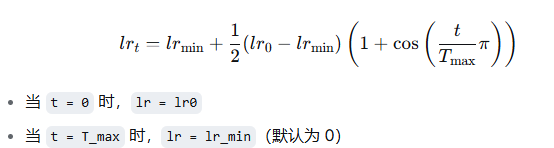

曲线大概是这样的：（下降速度先慢后快，最后平缓）


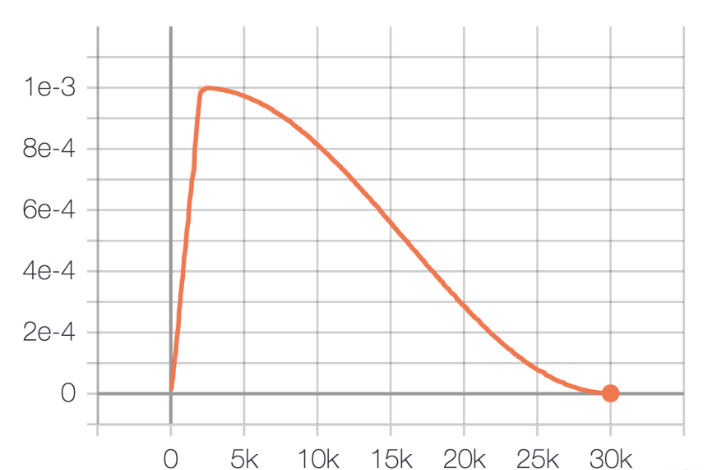

#### 参数$T_{max} = 1000$是什么意思？
$T_{max}$是一个完整余弦周期的迭代步数
学习率会从初始值逐渐降到最低，这个过程持续$T_{max} = 1000$步
当到达1000步后，学习率会下降到eta_min（默认是0），还可以设置CosineAnnealingLR的多周期重启，它还会跳回初始值重新开始

#### 为什么要用余弦退火？
首先训练后期只会用越来越小的学习率，防止剧烈震荡，帮助模型收敛到更好的极小值点
有时候配合热重启能够跳出局部最优
更加平滑更加自然


In [ ]:
def train(model, optimizer, scheduler, train_dataloader, device, epoch):
    model.train()
    total_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        ## 将数据转移到设备上
        x, y = x.to(device), y.to(device)
        
        ## 前向传播
        logits, loss = model(x, targets=y)

        ## 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ## 按照退火算法调整学习率
        scheduler.step()
        
        total_loss += loss.item()
        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item():.4f}')
    return total_loss


In [ ]:
def eval(model, val_loader, device):
    ## 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, loss = model(x, targets=y)
            val_loss += loss
    return val_loss

import tiktoken
enc = tiktoken.get_encoding("gpt2")
    

In [ ]:
# ## main
# for epoch in range(2):
#     train_loss = train(model, optimizer, scheduler, train_dataloader=train_data_loader, device=device, epoch=epoch)
#     val_loss = eval(model, val_loader=val_data_loader, device=device)
#     print(f'Epoch: {epoch}, Train Loss: {train_loss/len(train_data_loader):.4f}, Val Loss: {val_loss/len(val_data_loader):.4f}')

#     ## 保存模型
#     avg_val_loss = val_loss / len(val_data_loader)
#     checkpoint = {
#         "epoch": epoch,
#         "model_state_dict": model.state_dict(),
#         "optimizer_state_dict": optimizer.state_dict(),
#         "scheduler_state_dict": scheduler.state_dict(),
#         "val_loss": avg_val_loss
#     }

#     ## 保存每个epoch的模型
#     torch.save(checkpoint, f"./checkpoints/model_epoch_{epoch}.pt")


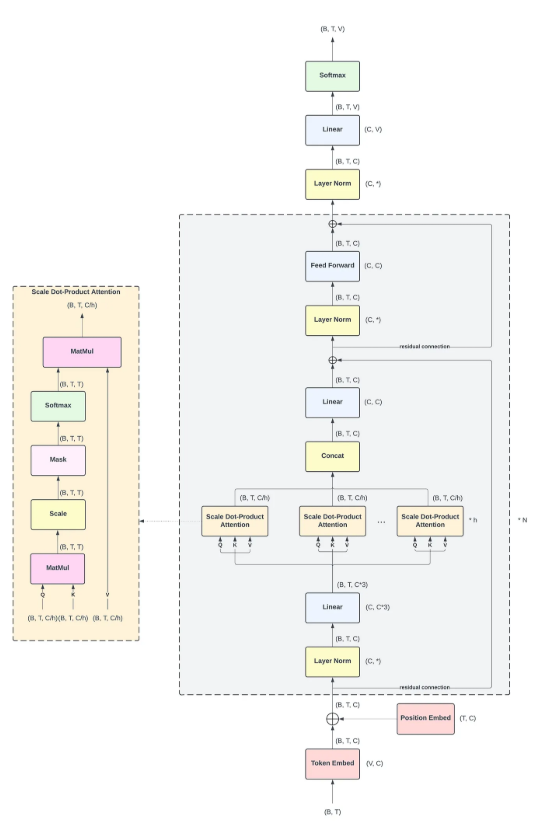

In [ ]:
# 定义专家

## SwiGLU 比普通 ReLU/GELU 好在梯度更平滑 + 容量更大，LLM 训练基本标配。
class SwiGLUEExpert(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.w1 = nn.Linear(config.hidden_dim, config.d_ff)
        self.w2 = nn.Linear(config.d_ff, config.hidden_dim)
        self.w3 = nn.Linear(config.hidden_dim, config.d_ff)
    
    def forward(self, x):
        gate = F.silu(self.w1(x))  ## 内置一个门控
        activation = self.w3(x)
        return self.w2(gate * activation)

In [ ]:
## 定义门控
class MoERouter(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.gate = nn.Linear(config.hidden_dim, config.router_expert_number)
        self.top_k = config.top_k
        self.shared_expert_number = config.shared_expert_number
        self.router_expert_number = config.router_expert_number
    
    def forward(self, x):  ## x shape (batch_size * seq_len, hidden_dim)
        router_logits = self.gate(x) ## router_logits shape(batch_size * seq_len, router_expert_number)
        router_prob = F.softmax(router_logits, dim=-1, dtype=torch.float)
        ## top_k会返回topk专家的输出和topk专家对应的索引
        top_k_prob, select_expert_index = torch.topk(router_prob, k=self.top_k, dim=-1) ## top_k_prob shape (batch_size, seq_len, top_k)
        ## top_k_prob, select_expert_index shape (batch_size * seq_len, top_k)
        ## 重新归一化(也不叫归一化)
        top_k_prob = top_k_prob / top_k_prob.sum(keepdim=True, dim=-1)
        ### 还原类型 
        top_k_prob = top_k_prob.to(x.dtype)

        ### 输出针对topk筛选后的掩码
        expert_mask = F.one_hot(
            select_expert_index,
            num_classes=self.router_expert_number,
        )

        expert_mask = expert_mask.permute(2, 1, 0)

        return router_logits, top_k_prob, select_expert_index, expert_mask



        

In [ ]:
### 定义MoE模块
class SparseMoE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.router_expert_number = config.router_expert_number
        self.shared_expert_number = config.shared_expert_number
        self.top_k = config.top_k

        ## 路由专家
        self.experts = nn.ModuleList(
            SwiGLUEExpert(config=config) for _ in range(self.router_expert_number)
        )
        ## 共享专家
        self.shared_experts = nn.ModuleList(
            SwiGLUEExpert(config=config) for _ in range(self.shared_expert_number)
        )
        self.router = MoERouter(config=config)

    def forward(self, x):
        batch_size, seq_len, hidden_dim = x.size()
        hidden_states = x.view(-1, hidden_dim)  # (batch_size * seq_len, hidden_dim)
        total_tokens = hidden_states.size(0)

        ## 共享专家的输出（所有token都经过）
        shared_output = torch.zeros_like(hidden_states)
        for shared_expert in self.shared_experts:
            shared_output = shared_output + shared_expert(hidden_states)
        if self.shared_expert_number > 0:
            shared_output = shared_output / self.shared_expert_number

        ## gate输出
        router_logits, top_k_prob, select_expert_index, expert_mask = self.router(hidden_states)
        # expert_mask shape: (router_expert_number, top_k, batch_size * seq_len)

        ## 负载均衡损失
        self._balance_loss_value = self.load_balance_loss(
            router_logits=router_logits, expert_mask=expert_mask
        )

        ## 注意 shape 应该是 (batch_size * seq_len, hidden_dim)
        final_hidden_states = torch.zeros(
            (total_tokens, hidden_dim),
            dtype=hidden_states.dtype,
            device=hidden_states.device
        )

        for expert_index in range(self.router_expert_number):
            expert_layer = self.experts[expert_index]
            current_expert_mask = expert_mask[expert_index]  # (top_k, total_tokens)

            index, top_x = torch.where(current_expert_mask)
            if top_x.numel() == 0:
                continue

            current_state = hidden_states[top_x, :]  # (num_selected, hidden_dim)
            current_state = expert_layer(current_state)
            current_token_router_weight = top_k_prob[top_x, index].unsqueeze(-1)
            current_hidden_states = current_state * current_token_router_weight

            final_hidden_states.index_add_(0, top_x, current_hidden_states.to(hidden_states.dtype))

        ## 加上共享专家的输出
        final_hidden_states = final_hidden_states + shared_output

        final_hidden_states = final_hidden_states.reshape(batch_size, seq_len, hidden_dim)
        return final_hidden_states, router_logits, self._balance_loss_value

    def load_balance_loss(self, router_logits, expert_mask):
        top1_mask = expert_mask[:, 0, :]              # (N, total_tokens)
        fraction = top1_mask.float().mean(dim=-1)     # (N,)
        probs = F.softmax(router_logits, dim=-1)      # (total_tokens, N)
        avg_prob = probs.mean(dim=0)                   # (N,)
        return self.router_expert_number * torch.sum(fraction * avg_prob)


In [ ]:
# block层，需要在这里加MoE
class Block_MoE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.att = MultiHeadAttention(config)  ## mha
        self.ffn = SparseMoE(config)
        self.ln1 = nn.LayerNorm(config.hidden_dim)
        self.ln2 = nn.LayerNorm(config.hidden_dim)

    def forward(self, x):
        x = x + self.att(self.ln1(x))
        final_hidden_states, _, _balance_loss_value = self.ffn(self.ln2(x))
        x = x + final_hidden_states
        self._balance_loss_value = _balance_loss_value
        
        return x

In [ ]:
class GPT_MoE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.block_size = config.block_size
        self.block = nn.Sequential(
            *[Block_MoE(config) for _ in range(config.n_layer)]
        )
        self.ln_final = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        self.tok_emb.weight = self.lm_head.weight

        ## 初始化权重
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        batch, seq_len = idx.size()
        token_emb = self.tok_emb(idx)
        position_emb = self.pos_emb(
            torch.arange(seq_len, device=idx.device)
        )
        x = token_emb + position_emb
        x = self.block(x)

        ## 收集每层的 balance_loss
        balance_loss = 0
        for block_item in self.block:
            balance_loss = balance_loss + block_item._balance_loss_value

        x = self.ln_final(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            batch, seq_len, vocab_size = logits.size()
            logits = logits.view(batch * seq_len, vocab_size)
            targets = targets.view(batch * seq_len)
            loss = F.cross_entropy(logits, targets)

        return logits, loss + balance_loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):  ## idx shape (batch_size, seq_len, hidden_dim)
            idx_cond = idx if idx.size(1) <= self.block_size else idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature  ## logits shape (batch_size, seq_len, hidden_dim)
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [ ]:
# ────────────────────────────────────────────────────────────────────
# Training utilities
# ────────────────────────────────────────────────────────────────────
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def get_grad_scaler(device, use_amp):
    if use_amp and device == "cuda":
        return torch.amp.GradScaler("cuda")
    return None


@torch.no_grad()
def estimate_loss(model, val_loader, device, ctx):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        with ctx:
            _, loss = model(x, targets=y)
        total_loss += loss.item() * x.size(0)
        total_tokens += x.size(0)
    model.train()
    return total_loss / total_tokens if total_tokens > 0 else float("inf")


def save_checkpoint(model, optimizer, scheduler, scaler, epoch, step, val_loss, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    ckpt = {
        "epoch": epoch,
        "step": step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_loss,
    }
    if scheduler is not None:
        ckpt["scheduler_state_dict"] = scheduler.state_dict()
    if scaler is not None:
        ckpt["scaler_state_dict"] = scaler.state_dict()
    torch.save(ckpt, os.path.join(save_dir, f"ckpt_epoch{epoch}_step{step}.pt"))
    print(f"[checkpoint] saved: epoch={epoch} step={step} val_loss={val_loss:.4f}")


def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    start_step = ckpt["step"] + 1
    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler is not None and "scheduler_state_dict" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if scaler is not None and "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    print(f"[checkpoint] loaded from {path}, resuming at epoch={start_epoch} step={start_step}")
    return start_epoch, start_step



In [ ]:
import time
from contextlib import nullcontext


def main():
    # ── hyperparameters ──
    data_path = "./mobvoi_seq_monkey_general_open_corpus.jsonl"
    max_data_lines = 1000
    batch_size = 4            # MoE 模型显存消耗大，酌情调小
    gradient_accumulation_steps = 4
    learning_rate = 3e-4
    weight_decay = 0.1
    betas = (0.9, 0.95)
    epochs = 10
    val_every_steps = 200
    save_every_epochs = 1
    generate_every_epochs = 1
    use_amp = True
    resume_from = None        # 设置 checkpoint 路径即可续训
    save_dir = "./checkpoints"

    # ── init ──
    device = get_device()
    config = GPTConfig()
    model = GPT_MoE(config)
    model = model.to(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {total_params / 1e6:.2f}M total, {trainable_params / 1e6:.2f}M trainable")
    print(f"Device: {device}")

    # ── data ──
    dataset = MyDataset(data_path, block_size=config.block_size, max_lines=max_data_lines)
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=(device == "cuda"))
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=(device == "cuda"))
    print(f"Data: {len(train_dataset)} train samples, {len(val_dataset)} val samples, {len(train_loader)} train batches")

    # ── optimizer & scheduler ──
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=betas)
    total_steps = (len(train_loader) // gradient_accumulation_steps) * epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

    # ── amp ──
    scaler = get_grad_scaler(device, use_amp)
    amp_ctx = torch.amp.autocast("cuda") if (use_amp and device == "cuda") else nullcontext()

    start_epoch = 0
    global_step = 0

    if resume_from is not None:
        start_epoch, global_step = load_checkpoint(resume_from, model, optimizer, scheduler, scaler)

    # ── training ──
    model.train()
    for epoch in range(start_epoch, epochs):
        epoch_loss = 0.0
        accumulated_loss = 0.0
        optimizer.zero_grad()
        t0 = time.time()

        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)

            with amp_ctx:
                _, loss = model(x, targets=y)
                loss = loss / gradient_accumulation_steps

            if scaler is not None:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            accumulated_loss += loss.item() * gradient_accumulation_steps

            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                if scaler is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

                scheduler.step()
                optimizer.zero_grad()
                global_step += 1

                if global_step % val_every_steps == 0:
                    val_loss = estimate_loss(model, val_loader, device, amp_ctx)
                    lr = scheduler.get_last_lr()[0]
                    elapsed = time.time() - t0
                    tokens_per_sec = (batch_size * config.block_size * val_every_steps * gradient_accumulation_steps) / elapsed
                    print(
                        f"epoch {epoch:2d} | step {global_step:5d} | "
                        f"loss {accumulated_loss / val_every_steps:.4f} | "
                        f"val_loss {val_loss:.4f} | "
                        f"lr {lr:.2e} | "
                        f"tok/s {tokens_per_sec:.0f}"
                    )
                    accumulated_loss = 0.0
                    t0 = time.time()

            # 前几个 batch 打印 loss 方便观察
            if batch_idx < 3 or (batch_idx + 1) % 100 == 0:
                current_lr = scheduler.get_last_lr()[0]
                print(f"  batch {batch_idx:4d} | loss {loss.item() * gradient_accumulation_steps:.4f} | lr {current_lr:.2e}")

        # ── end of epoch ──
        val_loss = estimate_loss(model, val_loader, device, amp_ctx)
        print(f"=== epoch {epoch} done | val_loss {val_loss:.4f} ===")

        if (epoch + 1) % save_every_epochs == 0:
            save_checkpoint(model, optimizer, scheduler, scaler, epoch, global_step, val_loss, save_dir)

        # 生成几个 token 看效果
        if (epoch + 1) % generate_every_epochs == 0:
            import tiktoken
            enc = tiktoken.get_encoding("gpt2")
            prompt = "The capital of France is"
            prompt_ids = enc.encode(prompt)
            x_gen = torch.tensor([prompt_ids], dtype=torch.long, device=device)
            out = model.generate(x_gen, max_new_tokens=30, temperature=0.8, top_k=50)
            generated = enc.decode(out[0].tolist())
            print(f"[generate] prompt: {prompt}")
            print(f"[generate] output: {generated}")
            print("───")

    print("Training complete.")


if __name__ == "__main__":
    main()
